<a href="https://colab.research.google.com/github/MaryamNourii/ECG-Signals/blob/Read-Data/ECG_ReadData_from_BD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!unzip '/content/drive/MyDrive/ecg/mit-bih-arrhythmia-database-1.0.0.zip'

Archive:  /content/drive/MyDrive/ecg/mit-bih-arrhythmia-database-1.0.0.zip
  inflating: mit-bih-arrhythmia-database-1.0.0/100.atr  
  inflating: mit-bih-arrhythmia-database-1.0.0/100.dat  
  inflating: mit-bih-arrhythmia-database-1.0.0/100.hea  
  inflating: mit-bih-arrhythmia-database-1.0.0/100.xws  
  inflating: mit-bih-arrhythmia-database-1.0.0/101.atr  
  inflating: mit-bih-arrhythmia-database-1.0.0/101.dat  
  inflating: mit-bih-arrhythmia-database-1.0.0/101.hea  
  inflating: mit-bih-arrhythmia-database-1.0.0/101.xws  
  inflating: mit-bih-arrhythmia-database-1.0.0/102-0.atr  
  inflating: mit-bih-arrhythmia-database-1.0.0/102.atr  
  inflating: mit-bih-arrhythmia-database-1.0.0/102.dat  
  inflating: mit-bih-arrhythmia-database-1.0.0/102.hea  
  inflating: mit-bih-arrhythmia-database-1.0.0/102.xws  
  inflating: mit-bih-arrhythmia-database-1.0.0/103.atr  
  inflating: mit-bih-arrhythmia-database-1.0.0/103.dat  
  inflating: mit-bih-arrhythmia-database-1.0.0/103.hea  
  inflating

In [ ]:
!pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.0/160.0 kB 3.7 MB/s eta 0:00:00


In [ ]:
!pip install matplotlib

In [ ]:
import wfdb
import numpy as np
from matplotlib import pyplot as plt
import glob

In [ ]:
dctLbls = {
          'N': ['N', '.', 'L', 'R', 'j', 'e'],
          'S' : ['A', 'a', 'S', 'J'],
          'F' :['V', 'E'],
          'V' :['F'],
          'U' :['Q','/', 'p', 'f']
          }

In [ ]:
fName= '/content/mit-bih-arrhythmia-database-1.0.0/'
fNames = glob.glob(fName + '*.dat')
fNames[0]

'/content/mit-bih-arrhythmia-database-1.0.0/209.dat'

In [ ]:
fNames[0].split('.dat')

['/content/mit-bih-arrhythmia-database-1.0.0/209', '']

In [ ]:
data0N = []
data0S = []
data0F = []
data0V = []
data0U = []

for name in fNames:
  fN = name.split('.dat')[0]
  signals, fileds = wfdb.rdsamp(fN)
  annotation = wfdb.rdann(fN, 'atr')
  fs = annotation.fs
  pos = annotation.sample
  lbls = annotation.symbol

  for i in range(1,len(pos)-1):
    indx = list(range(pos[i]-20,pos[i]+40))
    qrs0 = signals[indx,0]
    stype = lbls[i]

    if stype in dctLbls['N']:
      data0N.append(qrs0)
    elif stype in dctLbls['S']:
      data0S.append(qrs0)
    elif stype in dctLbls['F']:
      data0F.append(qrs0)
    elif stype in dctLbls['V']:
      data0V.append(qrs0)
    elif stype in dctLbls['U']:
      data0U.append(qrs0)


data0N = np.array(data0N, dtype = np.float64)
data0S = np.array(data0S, dtype = np.float64)
data0F = np.array(data0F, dtype = np.float64)
data0V = np.array(data0V, dtype = np.float64)
data0U = np.array(data0U, dtype = np.float64)

len(data0N), len(data0S), len(data0F), len(data0V), len(data0U)

(90589, 2779, 7236, 803, 8039)

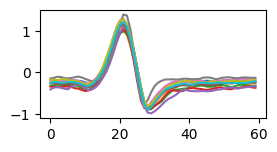

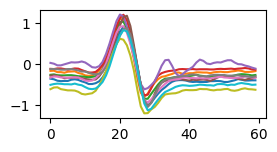

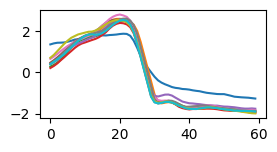

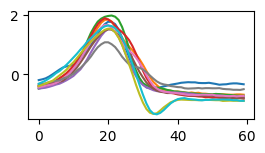

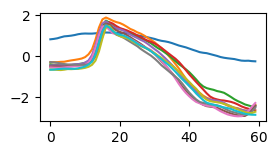

In [ ]:
plt.subplot(3,2,1)
plt.plot(data0N[:10].T)
plt.show()

plt.subplot(3,2,2)
plt.plot(data0S[:10].T)
plt.show()

plt.subplot(3,2,3)
plt.plot(data0F[:10].T)
plt.show()

plt.subplot(3,2,4)
plt.plot(data0V[:10].T)
plt.show()

plt.subplot(3,2,5)
plt.plot(data0U[:10].T)
plt.show()